# Fake Job Posting Detection
**Course:** Data Warehousing and Data Mining (CSE_4060) – ABL Component  
**Goal:** Binary classification (real vs fake job postings) using text & metadata features  
**Dataset:** Kaggle – Real / Fake Job Posting Prediction (~17,880 rows)  
**Focus:** High recall on fake class to minimize missed scams  
**Tools:** Python, scikit-learn, XGBoost, TF-IDF, WordCloud

In [5]:
import sys
print("Python path:", sys.executable)
print("Version:", sys.version.split()[0])

import pandas as pd
print("Pandas imported OK")

Python path: c:\MIT\VI Sem\PE1 - DATA WAREHOUSING AND MINING\Mini Project\fake-job-detection\.venv\Scripts\python.exe
Version: 3.13.2
Pandas imported OK


In [6]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("\nIs xgboost available?")
try:
    import xgboost
    print("Yes")
except:
    print("No – need to install")

Python executable: c:\MIT\VI Sem\PE1 - DATA WAREHOUSING AND MINING\Mini Project\fake-job-detection\.venv\Scripts\python.exe
Python version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]

Is xgboost available?
Yes


In [7]:
# ────────────────────────────────────────────────
# 1. IMPORT LIBRARIES & SETUP
# ────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (run once)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")

Setup complete.


In [8]:
# ────────────────────────────────────────────────
# DOWNLOAD THE MISSING punkt_tab MODEL (required for NLTK 3.8+)
# ────────────────────────────────────────────────

import nltk

print("Downloading punkt_tab...")
nltk.download('punkt_tab')

print("punkt_tab downloaded successfully!")

punkt_tab downloaded successfully!


[nltk_data] Downloading package punkt_tab to C:\Users\Teja
[nltk_data]     Thiriveedhi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
# ────────────────────────────────────────────────
# 2. LOAD THE DATASET
# ────────────────────────────────────────────────

import pandas as pd

# Adjust path if your notebook is in 'notebooks/' folder
DATA_PATH = "../data/fake_job_postings.csv"   # Go up one level from notebooks/ to reach data/

try:
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found! Check:")
    print("1. Is the file named exactly 'fake_job_postings.csv'?")
    print("2. Is it in the 'data/' folder?")
    print("Current working directory:", os.getcwd())
    raise

# Basic overview
print("\nShape (rows, columns):", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution (fraudulent column):")
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True).round(4) * 100)

# Peek at first few rows
df.head(3)

Dataset loaded successfully!

Shape (rows, columns): (17880, 18)

Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Target distribution (fraudulent column):
fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## Quick Observations (fill after running above cell)
- ~17,880 rows, 18 columns
- Target: fraudulent (0 = real, 1 = fake) → highly imbalanced (~95% real, ~5% fake)
- Important text columns: title, company_profile, description, requirements, benefits
- Useful binary/categorical: telecommuting, has_company_logo, has_questions, employment_type, etc.

Top missing value columns:


,Missing Count,Missing %
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


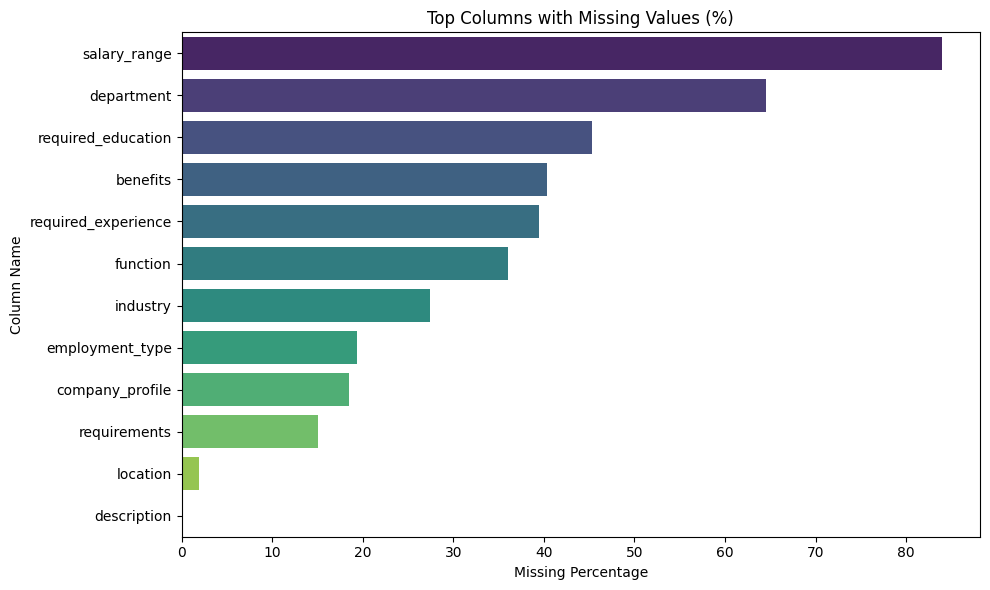

In [10]:
# ────────────────────────────────────────────────
# MISSING VALUES ANALYSIS
# ────────────────────────────────────────────────

missing_count = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).head(12)   # Top 12 most missing columns

print("Top missing value columns:")
display(missing_summary)

# Visual
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_summary['Missing %'], y=missing_summary.index, palette='viridis')
plt.title('Top Columns with Missing Values (%)')
plt.xlabel('Missing Percentage')
plt.ylabel('Column Name')
plt.tight_layout()
plt.show()

=== Original Class Distribution (Before Balancing) ===
fraudulent
0    17014
1      866
Name: count, dtype: int64

Percentage:
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

✅ Bar plot saved as 'class_imbalance_bar.png' (in your project folder)


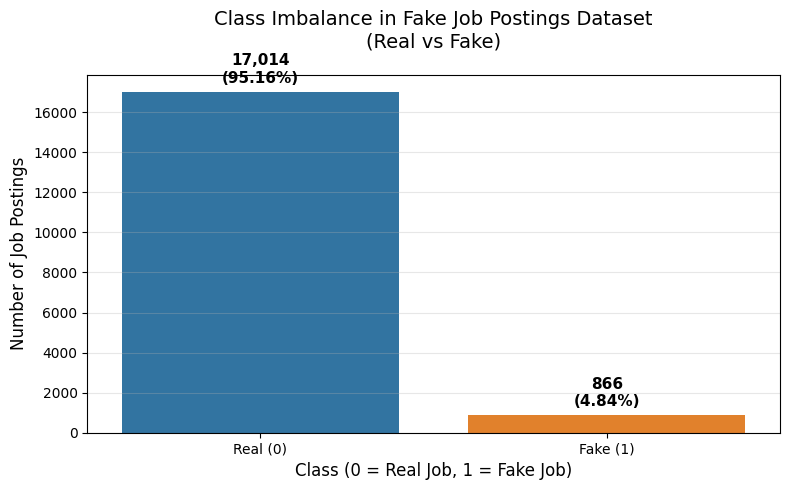

In [11]:
# ────────────────────────────────────────────────
# CLASS IMBALANCE GRAPH (Before Any Balancing)
# ────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Original class distribution
class_counts = df['fraudulent'].value_counts()
class_percent = df['fraudulent'].value_counts(normalize=True) * 100

print("=== Original Class Distribution (Before Balancing) ===")
print(class_counts)
print("\nPercentage:")
print(class_percent.round(2))

# === BAR PLOT (Recommended for PPT) ===
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_counts.index, 
                 y=class_counts.values, 
                 palette=['#1f77b4', '#ff7f0e'])

plt.title('Class Imbalance in Fake Job Postings Dataset\n(Real vs Fake)', 
          fontsize=14, pad=20)
plt.xlabel('Class (0 = Real Job, 1 = Fake Job)', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)

# Add count and percentage on bars
for i, count in enumerate(class_counts):
    plt.text(i, count + 300, 
             f'{count:,}\n({class_percent.iloc[i]:.2f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks([0, 1], ['Real (0)', 'Fake (1)'])
plt.grid(axis='y', alpha=0.3)

# Save high-quality image for PPT
plt.savefig('class_imbalance_bar.png', dpi=300, bbox_inches='tight')
print("\n✅ Bar plot saved as 'class_imbalance_bar.png' (in your project folder)")

plt.tight_layout()
plt.show()

In [12]:
# ────────────────────────────────────────────────
# KEY FEATURE INSIGHTS vs FRAUD
# ────────────────────────────────────────────────

key_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'employment_type']

print("=== Fraud Rate by Key Features ===\n")

for col in key_cols:
    if col in df.columns:
        print(f"→ {col.upper()}")
        vc = df[col].value_counts(dropna=False)
        print(vc)
        
        fraud_rate = (df.groupby(col, dropna=False)['fraudulent'].mean() * 100).round(2)
        print("\nFraud percentage within each category:")
        print(fraud_rate)
        print("-" * 50)

=== Fraud Rate by Key Features ===

→ TELECOMMUTING
telecommuting
0    17113
1      767
Name: count, dtype: int64

Fraud percentage within each category:
telecommuting
0    4.69
1    8.34
Name: fraudulent, dtype: float64
--------------------------------------------------
→ HAS_COMPANY_LOGO
has_company_logo
1    14220
0     3660
Name: count, dtype: int64

Fraud percentage within each category:
has_company_logo
0    15.93
1     1.99
Name: fraudulent, dtype: float64
--------------------------------------------------
→ HAS_QUESTIONS
has_questions
0    9088
1    8792
Name: count, dtype: int64

Fraud percentage within each category:
has_questions
0    6.78
1    2.84
Name: fraudulent, dtype: float64
--------------------------------------------------
→ EMPLOYMENT_TYPE
employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

Fraud percentage within each category:
employment_type
Contract     2.89

In [13]:
# ────────────────────────────────────────────────
# COMBINE TEXT COLUMNS FOR NLP
# ────────────────────────────────────────────────

# Columns to combine (focus on the richest text)
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# Fill NaN with empty string so we can concatenate safely
for col in text_cols:
    df[col] = df[col].fillna('')

# Create a single combined text column
df['full_text'] = df[text_cols].agg(' '.join, axis=1)

# Quick check
print("Combined text example (first job):")
print(df['full_text'].iloc[0][:500] + "...")  # first 500 chars

print("\nLength stats of full_text:")
print(df['full_text'].str.len().describe().round(0))

# Drop rows with almost no text (very rare)
df = df[df['full_text'].str.strip().str.len() > 10].copy()
print("\nRows after cleaning:", len(df))

Combined text example (first job):
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributor...

Length stats of full_text:
count    17880.0
mean      2670.0
std       1466.0
min         18.0
25%       1595.0
50%       2522.0
75%       3475.0
max      14945.0
Name: full_text, dtype: float64

Rows after cleaning: 17880


In [14]:
# ────────────────────────────────────────────────
# BASIC TEXT CLEANING FUNCTION
# ────────────────────────────────────────────────

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs, HTML tags, special chars
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    # Join back
    return ' '.join(tokens)

# Apply to full_text (this may take 1–2 minutes)
print("Cleaning text... (may take a minute)")
df['clean_text'] = df['full_text'].apply(clean_text)

print("\nExample cleaned text:")
print(df['clean_text'].iloc[0][:300] + "...")

Cleaning text... (may take a minute)

Example cleaned text:
marketing intern food weve created groundbreaking awardwinning cooking site support connect celebrate home cook give everything need one placewe top editorial business engineering team focused using technology find new better way connect people around specific food interest offer superb highly curat...


Generating word clouds...


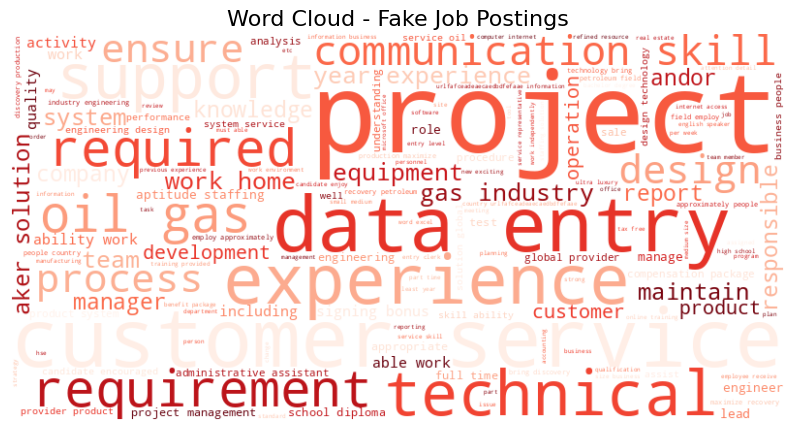

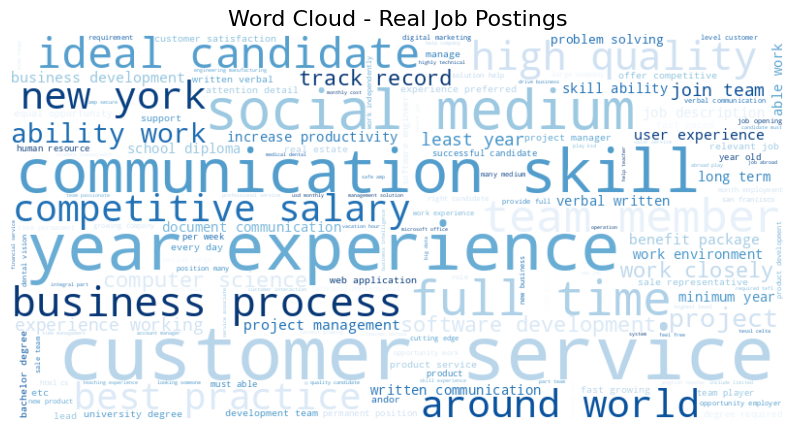

In [15]:
# ────────────────────────────────────────────────
# WORD CLOUDS: Fake vs Real
# ────────────────────────────────────────────────

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(text_series, title, color):
    text = ' '.join(text_series.dropna())
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap=color,
                          max_words=150,
                          contour_color='steelblue').generate(text)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Fake vs Real
print("Generating word clouds...")

generate_wordcloud(df[df['fraudulent'] == 1]['clean_text'], 
                   "Word Cloud - Fake Job Postings", 
                   'Reds')

generate_wordcloud(df[df['fraudulent'] == 0]['clean_text'], 
                   "Word Cloud - Real Job Postings", 
                   'Blues')

In [11]:
# ────────────────────────────────────────────────
# FEATURE EXTRACTION: TF-IDF + Meta Features
# ────────────────────────────────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE  # for imbalance later

# Text vectorizer (TF-IDF on clean_text)
tfidf = TfidfVectorizer(
    max_features=5000,          # limit to top 5000 words (balances speed & performance)
    ngram_range=(1, 2),         # unigrams + bigrams for better context
    min_df=5,                   # ignore rare words
    stop_words='english'
)

# Meta/numerical features (strong signals from EDA)
meta_cols = ['telecommuting', 'has_company_logo', 'has_questions']

# Preprocessor: TF-IDF for text + passthrough for meta
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', tfidf, 'clean_text'),
        ('meta', 'passthrough', meta_cols)
    ]
)

# Prepare X (features) and y (target)
X_text_meta = df[['clean_text'] + meta_cols]
y = df['fraudulent']

print("Feature prep ready. Shape before transform:", X_text_meta.shape)

Feature prep ready. Shape before transform: (17880, 4)


Train shape after TF-IDF: (14304, 5003)

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.54      0.90      0.67       173

    accuracy                           0.96      3576
   macro avg       0.77      0.93      0.82      3576
weighted avg       0.97      0.96      0.96      3576

ROC-AUC: 0.9872


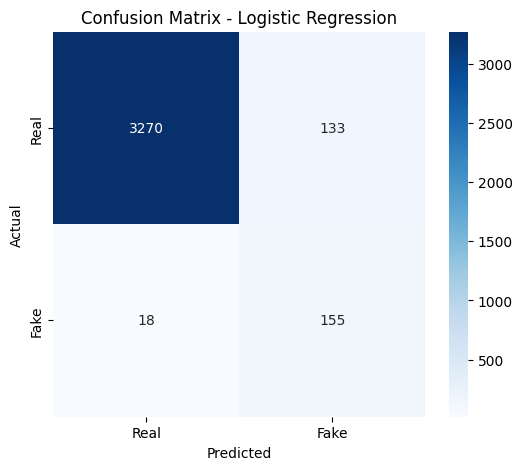

In [12]:
# ────────────────────────────────────────────────
# TRAIN/TEST SPLIT & BASELINE MODEL (CORRECTED)
# ────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Split (stratified because of imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_text_meta, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_STATE
)

# Transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Train shape after TF-IDF:", X_train_transformed.shape)

# Logistic Regression with balanced weights
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr.fit(X_train_transformed, y_train)
y_pred_lr = lr.predict(X_test_transformed)
y_prob_lr = lr.predict_proba(X_test_transformed)[:, 1]

# Results
print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

# Fixed ROC-AUC print
auc = roc_auc_score(y_test, y_prob_lr)
print(f"ROC-AUC: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.76      0.80      0.78       173

    accuracy                           0.98      3576
   macro avg       0.88      0.89      0.88      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9862


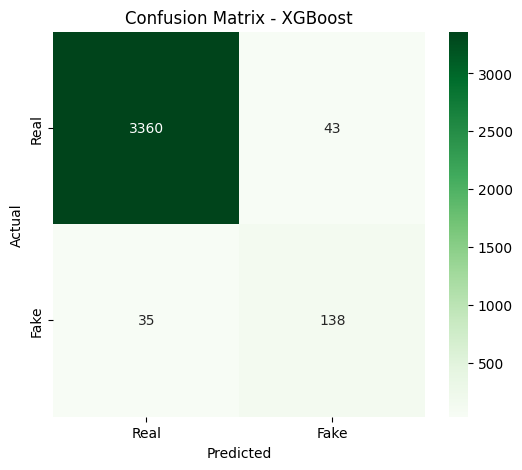


Top 15 Most Important Features:
encouraged           0.021896
quality candidate    0.020715
exceed               0.016500
facilitating         0.014781
finance option       0.013399
real estate          0.013274
work home            0.013099
help develop         0.012982
size                 0.012844
initiate             0.012537
inquiry              0.012034
nontechnical         0.010745
has_company_logo     0.009579
transportation       0.008783
product service      0.008682
dtype: float32


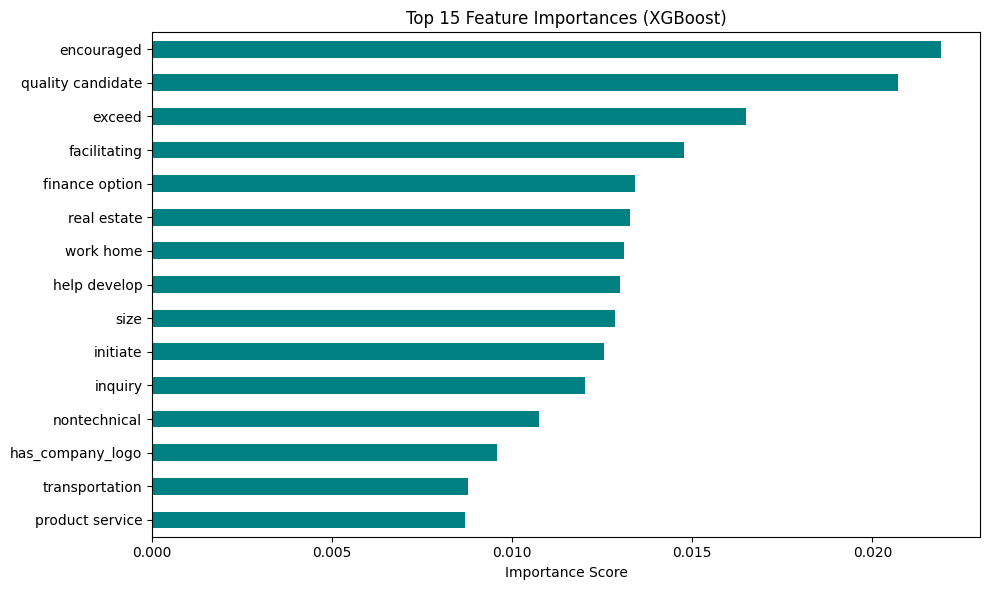

In [13]:
# ────────────────────────────────────────────────
# XGBoost Model + Feature Importance
# ────────────────────────────────────────────────

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# XGBoost (handles imbalance well with scale_pos_weight)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # approx 19.7

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    n_jobs=-1
)

xgb.fit(X_train_transformed, y_train)

y_pred_xgb = xgb.predict(X_test_transformed)
y_prob_xgb = xgb.predict_proba(X_test_transformed)[:, 1]

print("\nXGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC: {auc_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance (top 15)
# Get feature names: TF-IDF + meta
tfidf_features = preprocessor.named_transformers_['tfidf'].get_feature_names_out()
meta_features = meta_cols
all_features = list(tfidf_features) + meta_features

importances = pd.Series(xgb.feature_importances_, index=all_features)
top_features = importances.sort_values(ascending=False).head(15)

print("\nTop 15 Most Important Features:")
print(top_features)

# Plot
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# ────────────────────────────────────────────────
# SAVE FITTED MODELS & PREPROCESSOR FOR LATER USE
# ────────────────────────────────────────────────

import joblib

# Save preprocessor and model
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(xgb, 'xgb_model.pkl')

print("Models saved successfully!")
print("Files created: preprocessor.pkl, xgb_model.pkl")

Models saved successfully!
Files created: preprocessor.pkl, xgb_model.pkl


In [15]:
# ────────────────────────────────────────────────
# PREDICTION FUNCTION – Fully Self-Contained (Loads Saved Models)
# ────────────────────────────────────────────────

import re
import pandas as pd
import joblib
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ─── Load saved preprocessor and model ───
try:
    preprocessor = joblib.load('preprocessor.pkl')
    xgb = joblib.load('xgb_model.pkl')
    print("Models loaded successfully!")
except FileNotFoundError:
    print("Error: preprocessor.pkl or xgb_model.pkl not found!")
    print("Please run the 'SAVE MODELS' cell first after training.")
    raise

# ─── Text cleaning function ───
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

# ─── Prediction function ───
def predict_fake_job(title="", company_profile="", description="", requirements="", benefits="",
                     telecommuting=0, has_company_logo=1, has_questions=1):
    """
    Predict if a job posting is fake or real.
    Returns: ('Real'/'Fake', fake probability %)
    """
    full_text = f"{title} {company_profile} {description} {requirements} {benefits}"
    clean = clean_text(full_text)
    
    input_df = pd.DataFrame({
        'clean_text': [clean],
        'telecommuting': [telecommuting],
        'has_company_logo': [has_company_logo],
        'has_questions': [has_questions]
    })
    
    input_transformed = preprocessor.transform(input_df)
    prob_fake = xgb.predict_proba(input_transformed)[0][1]
    label = "Fake" if prob_fake > 0.5 else "Real"
    
    return label, round(prob_fake * 100, 2)

# ──── Test Examples ────
print("Example 1 (Real-looking job):")
print(predict_fake_job(
    title="Python Developer",
    company_profile="Tech startup in Bangalore",
    description="We are looking for experienced Python developers with strong problem-solving skills...",
    requirements="3+ years experience, Django knowledge",
    benefits="Competitive salary, health insurance, flexible hours",
    telecommuting=0,
    has_company_logo=1,
    has_questions=1
))

print("\nExample 2 (Suspicious scam):")
print(predict_fake_job(
    title="Work From Home - Earn ₹50,000 Daily",
    company_profile="",
    description="No experience needed! Urgent hiring for data entry. Payment daily via bank. Apply now!",
    requirements="Just a smartphone and internet",
    benefits="Unlimited income, no target",
    telecommuting=1,
    has_company_logo=0,
    has_questions=0
))

Models loaded successfully!
Example 1 (Real-looking job):
('Real', np.float32(0.55))

Example 2 (Suspicious scam):
('Fake', np.float32(99.79))
